In [65]:
import sys

import numpy as np
import math
import cmath

import meep as mp
from meep import materials
import meep.visualization as vis

import pandas as pd
import itertools

import matplotlib.pyplot as plt



In [66]:
def expand_grid(data_dict):
    rows = itertools.product(*data_dict.values())
    return pd.DataFrame.from_records(rows, columns=data_dict.keys())



  

In [70]:
angle_deg = 10
freq_THz = 245

ph = 0.44
pr = 0.14
ppx = 0.6
ppy = 0.6

resolution = 50 # fdtd grid resolution

theta_r = math.radians(angle_deg) # convert angle to radians

fcen = freq_THz/300 # source center wavelength
df = fcen * 0.005

dpml = 1 # perfectly matched layer thickness
dpad = 5 * ph # thickness of glass above/below PhC

# cell dimensions
sx = ppx 
sy = ppy
sz = dpml + dpad + ph + dpad + dpml

cell_size = mp.Vector3(sx, 0, sz)

# cell Z boundary
pml_layers = [mp.PML(thickness=dpml, direction=mp.Z)]

k_point = mp.Vector3(0, 0, fcen * 1.45).rotate(mp.Vector3(0, 1, 0), theta_r)

src_pt = mp.Vector3(0,0, 0.5 * (sz - 2 * dpml - ph))
ref_mon_pt = mp.Vector3(0,0, 0.5 * (dpad + dpml))
trans_mon_pt = mp.Vector3(0,0, -0.5 * (ph + dpad + dpml))

default_material = mp.Medium(index = 1.45)

geometry = [
    mp.Block( 
        material = mp.Medium(index = 3.67), 
        size = mp.Vector3(2*pr, mp.inf, ph),
        center = mp.Vector3()
    )
]

def pw_amp(k, x0):
    def _pw_amp(x):
        return cmath.exp(1j * 2 * math.pi * k.dot(x + x0))
    
    return _pw_amp

sources = [
    mp.Source(
        mp.ContinuousSource(fcen, fwidth = df), 
        component = mp.Ey, 
        center = src_pt,
        size = mp.Vector3(sx, 0, 0), 
        amp_func=pw_amp(k_point, src_pt)
    )
]

symmetries = []

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k_point,
    sources=sources, 
    symmetries = symmetries, 
    default_material = default_material
)

base_flux = sim.add_flux(
    fcen, 
    0, 
    1, 
    mp.FluxRegion(center = trans_mon_pt, size = mp.Vector3(sx, 0, 0))
)

sim.run(until = 50)

b_flux = mp.get_fluxes(base_flux)
b_flux_data = sim.get_flux_data(base_flux)

sim.reset_meep()

sim2 = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k_point,
    sources=sources, 
    default_material = default_material, 
    geometry=geometry,
    symmetries = symmetries
)

trans_flux = sim2.add_flux(
    fcen, 
    0, 
    1, 
    mp.FluxRegion(center = trans_mon_pt, size = mp.Vector3(sx, 0, 0))
)

sim2.run(until = 50)

t_flux = mp.get_fluxes(trans_flux)
Tflux = t_flux[0]/b_flux[0]

print(Tflux)



-----------
Initializing structure...
time for choose_chunkdivision = 2.59876e-05 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.02 x 6.84 with resolution 50
time for set_epsilon = 0.013025 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=50.0)

run 0 finished at t = 50.0 (5000 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 2.09808e-05 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.02 x 6.84 with resolution 50
     block, center = (0,0,0)
          size (0.28,1e+20,0.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13.4689,13.4689,13.4689)
time for set_epsilon = 0.0146861 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=50.0)

run 0 finished at t = 50.0 (5000 timesteps)
0.33255456582047166


     block, center = (0,0,0)
          size (0.28,1e+20,0.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (13.4689,13.4689,13.4689)


<Axes: >

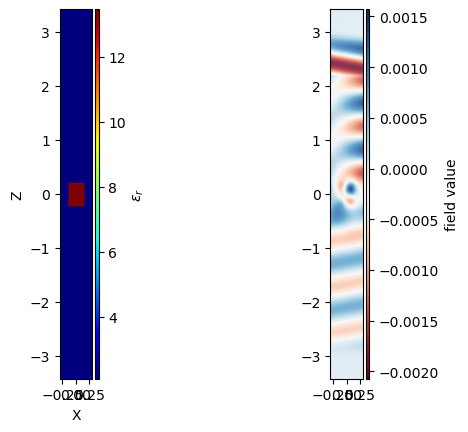

In [71]:



fig, ax = plt.subplots(1,2)
#gruh = sim.plot2D(eps_parameters =  {
#    "interpolation": "spline36",
#    "cmap": "binary",
#    "alpha": 1.0,
#    "contour": False,
#    "contour_linewidth": 1,
#    "frequency": None,
#    "resolution": None,
#    "colorbar": True,
#}, 
#output_plane=mp.Volume(center = mp.Vector3(), size = mp.Vector3(sx, 0, sz)), ax=ax)
vis.plot_eps(
    sim = sim2, 
    ax = ax[0], 
    output_plane=mp.Volume(
        center = mp.Vector3(), 
        size = mp.Vector3(sx, 0, sz)),
    eps_parameters =  {
        "interpolation": "spline36",
        "cmap": "jet",
        "alpha": 1.0,
        "contour": False,
        "contour_linewidth": 1,
        "frequency": None,
        "resolution": None,
        "colorbar": True,
    }, 
    colorbar_parameters={
        "label": None,
        "orientation": "vertical",
        "extend": None,
        "position": "right",
        "size": "10%",
        "pad": "10%",
    }
    
)
vis.plot_fields(
    sim = sim2, 
    fields=mp.Ey,
    ax = ax[1], 
    output_plane=mp.Volume(
        center = mp.Vector3(), 
        size = mp.Vector3(sx, 0, sz)),
    field_parameters={
        "interpolation": "spline36",
        "cmap": "RdBu",
        "alpha": 0.8,
        "post_process": np.real,
        "colorbar": True,
    },
    colorbar_parameters={
        "label": None,
        "orientation": "vertical",
        "extend": None,
        "position": "right",
        "size": "10%",
        "pad": "10%",
    }
    
)





